In [69]:
#purpose: open MASTER FIREX AQ FRP data for 2019 Western US fires and compare to VIIRS dets + candidates

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import cartopy
import cartopy.crs as ccrs
import datetime as dt
import netCDF4
import matplotlib as mpl
from matplotlib.lines import Line2D

#for map gridlines:
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

#for NIFC matching:
import geopandas as gpd
from shapely.geometry import Polygon, LineString, Point

In [8]:
#approach:
#extract all 2019 W.US. VIIRS data (script 5)
#extract all fire mask points, lon, lat, start/stop dates from MASTER
#look for overlap in space and time

#viirs data 2019
#dets = pd.read_csv('/home/scoffie1/WUS_2019_candidates.csv')
dets = pd.read_csv('/projects/shared-buckets/coffield/viirs/outputs/western_us/2019_07_dets_SNPP.csv',
                  usecols = ['longitude','latitude','fire_mask','confidence','acq_date','acq_time','acq_datetime','vza'])
dets['satellite'] = 'SNPP'

dets2 = pd.read_csv('/projects/shared-buckets/coffield/viirs/outputs/western_us/2019_07_dets_NOAA20.csv',
                usecols = ['longitude','latitude','fire_mask','confidence','acq_date','acq_time','acq_datetime','vza'])
dets2['satellite'] = 'NOAA20'

dets = pd.concat([dets, dets2]).reset_index(drop=True)
dets.acq_datetime = pd.to_datetime(dets.acq_datetime)

dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,satellite
0,-103.368050,48.402280,8.0,n,2019-07-24,07:42,2019-07-24 07:42:00+00:00,53.1699,SNPP
1,-103.367720,48.403957,8.0,n,2019-07-24,07:42,2019-07-24 07:42:00+00:00,53.1610,SNPP
2,-102.641365,48.369510,8.0,n,2019-07-24,07:42,2019-07-24 07:42:00+00:00,52.3339,SNPP
3,-102.918790,48.228890,8.0,n,2019-07-24,07:42,2019-07-24 07:42:00+00:00,52.6452,SNPP
4,-102.711210,48.228300,8.0,n,2019-07-24,07:42,2019-07-24 07:42:00+00:00,52.4051,SNPP
...,...,...,...,...,...,...,...,...,...
1262523,-116.829636,47.371970,5.0,x,2019-08-16,21:12,2019-08-16 21:12:00+00:00,39.6262,NOAA20
1262524,-116.836530,47.371520,8.0,n,2019-08-16,21:12,2019-08-16 21:12:00+00:00,39.6084,NOAA20
1262525,-116.837600,47.376020,5.0,x,2019-08-16,21:12,2019-08-16 21:12:00+00:00,39.6084,NOAA20
1262526,-116.855920,47.411330,8.0,n,2019-08-16,21:12,2019-08-16 21:12:00+00:00,39.5728,NOAA20


In [9]:
def scale_bar(ax, length=None, location=(0.15, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    credit: https://stackoverflow.com/questions/32333870/how-can-i-show-a-km-ruler-on-a-cartopy-matplotlib-plot
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(ccrs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = ccrs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0] + 200           #SHIFTED 200 M TO THE RIGHT
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby+100, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom', fontsize=9)

In [14]:
#2020s
nifc_perimeters = gpd.read_file('https://services3.arcgis.com/T4QMspbfLg3qTGWY/ArcGIS/rest/services/InterAgencyFirePerimeterHistory_2020s_Read_Only/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson')

In [20]:
#2019
nifc_perimeters = gpd.read_file('https://services3.arcgis.com/T4QMspbfLg3qTGWY/ArcGIS/rest/services/Historic_GeoMAC_Perimeters_2019/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson')

In [ ]:
#plot all figures individually 

#define colormap for MASTER fire mask
cmap = mpl.colors.ListedColormap(['gray','orange','red','black', 'purple','blue'])
bounds = [0,1,2,253,254,255,256]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
legend = ['0-No fire','1-Smoldering', '2-Flaming', '253-Saturated', '254-Unclassfied', '255-Bad data']
labels = [i.split('-')[1] for i in legend]

count = 0

master_dir = '/projects/shared-buckets/coffield/master/2019/'
files = os.listdir(master_dir)
files = sorted([f for f in files if f[-2:]=='nc'])

for file in files:
    data = xr.open_dataset(master_dir + file)
    date = dt.datetime.strptime(file[21:34], '%Y%m%d_%H%M').replace(tzinfo=dt.timezone.utc)
    
    locs = (data.MASK >0)    
    lon_mean = np.array(data.Longitude)[locs].mean()
    lat_mean = np.array(data.Latitude)[locs].mean()
    
    subset = dets[np.abs(dets.acq_datetime - date) < dt.timedelta(hours=2)] #within 2 hr
    subset = subset[(np.abs(subset.longitude - lon_mean) < 0.1) & (np.abs(subset.latitude - lat_mean) <0.1 )] 
    
    if len(subset) > 0:
        #plot them together, one for each unique matching overpass

        overpasses = np.unique(subset.acq_time)
        for overpass in overpasses:
            subsubset = subset[subset.acq_time==overpass]
            vza = subsubset.vza.mean()

            fig, ax = plt.subplots(1,1, subplot_kw={'projection': ccrs.Miller()}, constrained_layout=True, figsize=(5,5))
    
            plot = ax.pcolormesh(data.Longitude, data.Latitude, data.MASK, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
            ax.text(0.75,0.95, f'VZA = {vza:.1f}$^\circ$', transform=ax.transAxes, fontsize=12, fontweight='bold')
            #cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.6, pad=0.01, ax=ax)
            #cbar.ax.tick_params(labelsize=13)
            #cbar.ax.set_xticks([0.5, 1.5, 127.5, 253.5, 254.5, 255.5])
            #cbar.ax.set_xticklabels(labels, rotation=45, ha='right')
            #cbar.set_label('MASTER fire mask')#, size=13)
    
            knowns = subsubset[subsubset.fire_mask > 6]
            cands = subsubset[subsubset.fire_mask < 7]
            ax.scatter(knowns.longitude, knowns.latitude, c='firebrick', edgecolors='1', s=50, alpha=0.6, transform=ccrs.Geodetic(), label='VIIRS known detections')
            ax.scatter(cands.longitude, cands.latitude, c='deepskyblue', edgecolors='1', s=50, alpha=0.6, transform=ccrs.Geodetic(), label='VIIRS candidate detections')
        
            mastertime = (date - dt.timedelta(hours=7)).strftime('%H:%M') 
            viirstime = str(subsubset.acq_time.iloc[0])
            viirstime = f'{int(viirstime[:2])-7}{viirstime[2:]}' 
            ax.set_title('{}\nMASTER flight at {} PDT\n{} VIIRS overpass at {} PDT'.format(date.strftime('%m/%d/%Y'), mastertime, subsubset.satellite.iloc[0], viirstime), fontsize=11)
                
            #plt.legend(loc=1)
            scale_bar(ax, 1)

            count+=1

            #plt.savefig(f'/projects/my-public-bucket/figures/figS1_panel{count}.png', dpi=125)
        
print('done', count, 'matches')

(0.0, 1.0, 0.0, 1.0)

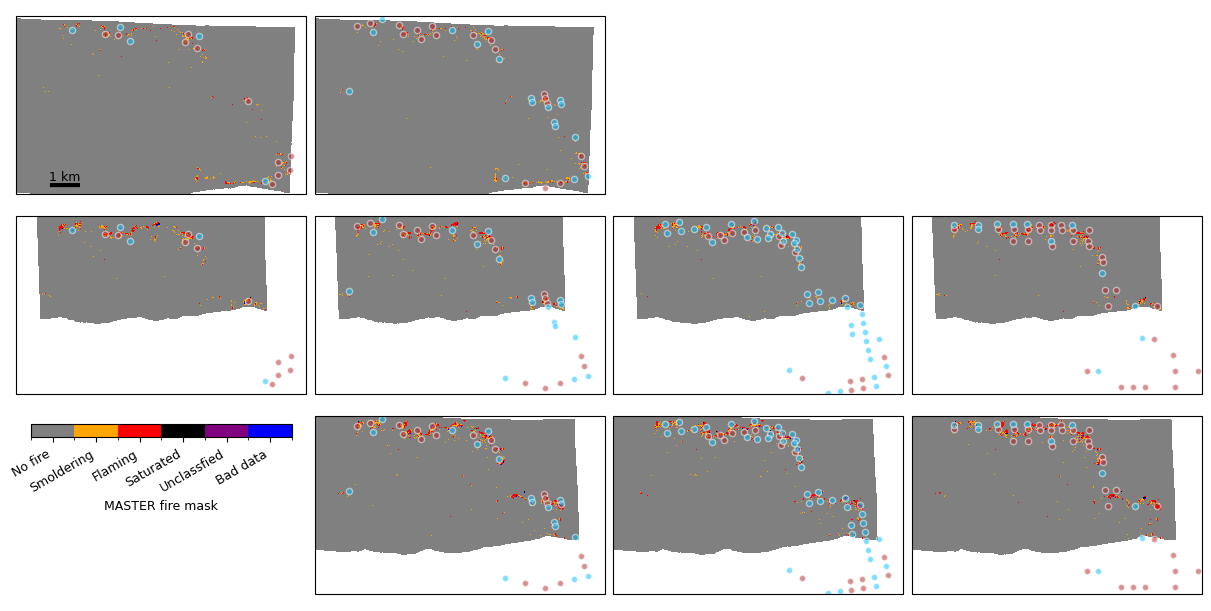

In [9]:
#modified version - 9 Williams Flats Panels Fig S1
master_dir = '/projects/shared-buckets/coffield/master/2019/'

files = ['MASTERFRP_1981719_02_20190806_1851_1900_V01.nc',
         'MASTERFRP_1981719_05_20190806_2033_2039_V01.nc',
         'MASTERFRP_1981719_06_20190806_2153_2156_V01.nc']

extent = [-118.60,-118.45, 47.94,48.012]

fig, axs = plt.subplots(3,4, subplot_kw={'projection': ccrs.Miller()}, constrained_layout=True, figsize=(12,6))
axs = axs.flat
a = [0,1,4,5,6,7,9,10,11]
i = 0

for file in files:
    data = xr.open_dataset(master_dir + file)
    date = dt.datetime.strptime(file[21:34], '%Y%m%d_%H%M').replace(tzinfo=dt.timezone.utc)
    
    locs = (data.MASK >0)    
    lon_mean = np.array(data.Longitude)[locs].mean()
    lat_mean = np.array(data.Latitude)[locs].mean()
    
    subset = dets[np.abs(dets.acq_datetime - date) < dt.timedelta(hours=2)] #within 2 hr
    subset = subset[(np.abs(subset.longitude - lon_mean) < 0.1) & (np.abs(subset.latitude - lat_mean) <0.1 )] 
    
    if len(subset) > 0:
        #plot them together, one for each unique matching overpass

        overpasses = np.unique(subset.acq_time)
        for overpass in overpasses:
            subsubset = subset[subset.acq_time==overpass]
    
            #extent = [data.Longitude.min(),  data.Longitude.max(),  data.Latitude.min(), data.Latitude.max()]

            axs[a[i]].set_extent(extent, crs=ccrs.PlateCarree())
                    
            plot = axs[a[i]].pcolormesh(data.Longitude, data.Latitude, data.MASK, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
    
            knowns = subsubset[subsubset.fire_mask > 6]
            cands = subsubset[subsubset.fire_mask < 7]
            axs[a[i]].scatter(knowns.longitude, knowns.latitude, c='firebrick', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS known detections')
            axs[a[i]].scatter(cands.longitude, cands.latitude, c='deepskyblue', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS candidate detections')

            mastertime = (date - dt.timedelta(hours=7)).strftime('%H:%M')
            viirstime = str(int(overpass[:2])-7) + overpass[2:]
            #axs[a[i]].set_title('{}\nMASTER flight at {} UTC\n{} VIIRS overpass at {} UTC'.format(date.strftime('%m/%d/%Y'), mastertime, subsubset.satellite.iloc[0], viirstime, fontsize=9))
            
            i+=1

scale_bar(axs[0], 1)

#define colormap for MASTER fire mask
cmap = mpl.colors.ListedColormap(['gray','orange','red','black', 'purple','blue'])
bounds = [0,1,2,253,254,255,256]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
legend = ['0-No fire','1-Smoldering', '2-Flaming', '253-Saturated', '254-Unclassfied', '255-Bad data']
labels = [i.split('-')[1] for i in legend]

cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.9, pad=-0.9, ax=axs[-4])
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_xticks([0.5, 1.5, 127.5, 253.5, 254.5, 255.5])
cbar.ax.set_xticklabels(labels, rotation=30, ha='right')
cbar.set_label('MASTER fire mask', size=9)
axs[-4].axis('off')
axs[2].axis('off')
axs[3].axis('off')


#plt.savefig('/projects/my-public-bucket/figures/figS1_master_9panel', dpi=150)

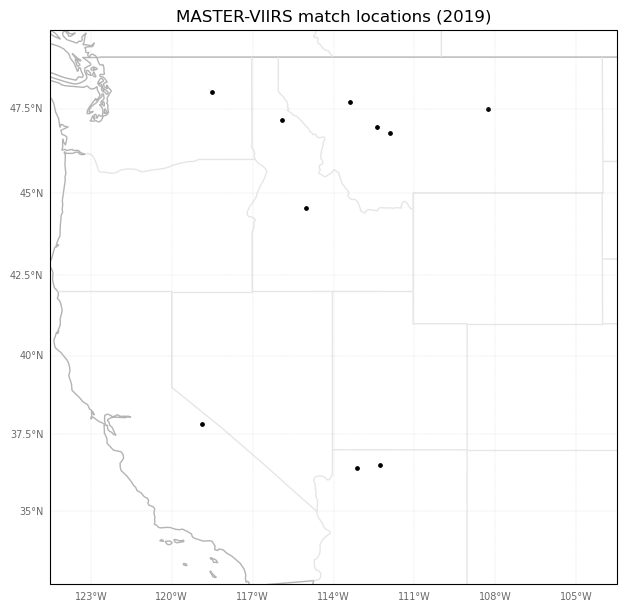

In [73]:
#See where all the available samples fall in the Western US -> 6 distinct fires
#Fig S3

fig, ax = plt.subplots(1,1, subplot_kw={'projection': cartopy.crs.Miller()}, constrained_layout=True, figsize=(7,6))
ax.set_extent([-124.5,-103.5,32.6,49.3]) #Western US

states_provinces = cartopy.feature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(cartopy.feature.BORDERS, edgecolor='0.7')
ax.add_feature(cartopy.feature.COASTLINE, edgecolor='0.7')
ax.add_feature(states_provinces, edgecolor='0.9')

for file in files:
    data = xr.open_dataset(master_dir + file)
    date = dt.datetime.strptime(file[21:34], '%Y%m%d_%H%M').replace(tzinfo=dt.timezone.utc)
    
    locs = (data.MASK >0)    
    lon_mean = np.array(data.Longitude)[locs].mean()
    lat_mean = np.array(data.Latitude)[locs].mean()
    
    subset = dets[np.abs(dets.acq_datetime - date) < dt.timedelta(hours=2)] #within 2 hr
    subset = subset[(np.abs(subset.longitude - lon_mean) < 0.1) & (np.abs(subset.latitude - lat_mean) <0.1 )] 
    
    if len(subset) > 0:
        
        ax.scatter(lon_mean, lat_mean, c='k', edgecolors='1', s=20, transform=ccrs.Geodetic())

ax.set_title('MASTER-VIIRS match locations (2019)')

#gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='0.8', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = True
gl.ylines = True
#gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
#gl.xformatter = LONGITUDE_FORMATTER
#gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 7, 'color': 'dimgray'}
gl.ylabel_style = {'size': 7, 'color': 'dimgray'}

(0.0, 1.0, 0.0, 1.0)

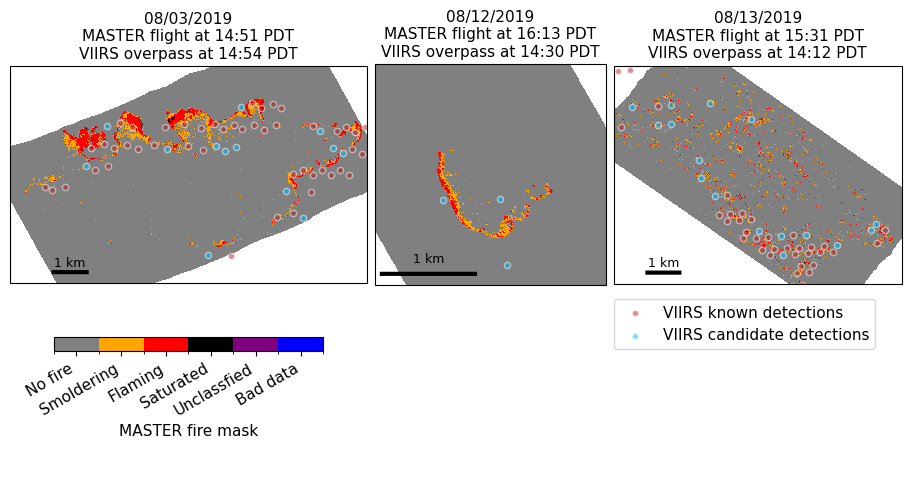

In [5]:
#modified version - plot 3 examples together for Fig 1
fig, axs = plt.subplots(2,3, subplot_kw={'projection': ccrs.Miller()}, constrained_layout=True,
                        gridspec_kw={'width_ratios':[1.55,1,1.25], 'height_ratios':[4,1]}, figsize=(9,5))
axs = axs.flat
a = 0

cmap = mpl.colors.ListedColormap(['gray','orange','red','black', 'purple','blue'])
bounds = [0,1,2,253,254,255,256]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
legend = ['0-No fire','1-Smoldering', '2-Flaming', '253-Saturated', '254-Unclassfied', '255-Bad data']
labels = [i.split('-')[1] for i in legend]

example_files = ['MASTERFRP_1981718_05_20190803_2151_2159_V01.nc',
    'MASTERFRP_1981722_07_20190812_2313_2315_V01.nc',
    'MASTERFRP_1981723_02_20190813_2231_2237_V01.nc']

for file in example_files:
    data = xr.open_dataset(master_dir + file)
    date = dt.datetime.strptime(file[21:34], '%Y%m%d_%H%M').replace(tzinfo=dt.timezone.utc)
    
    locs = (data.MASK >0)    
    lon_mean = np.array(data.Longitude)[locs].mean()
    lat_mean = np.array(data.Latitude)[locs].mean()
    
    subset = dets[np.abs(dets.acq_datetime - date) < dt.timedelta(hours=2)] #within 2 hr
    subset = subset[(np.abs(subset.longitude - lon_mean) < 0.1) & (np.abs(subset.latitude - lat_mean) <0.1 )] 

    overpasses = np.unique(subset.acq_time)
    overpass = [overpass for overpass in overpasses if overpass in ['21:54','21:30','21:12']][0]

    subsubset = subset[subset.acq_time==overpass]
    
    extent = [data.Longitude.min()+0.01,  data.Longitude.max()-0.01,  data.Latitude.min()+0.01, data.Latitude.max()-0.01]
    axs[a].set_extent(extent, crs=ccrs.PlateCarree())
    plot = axs[a].pcolormesh(data.Longitude, data.Latitude, data.MASK, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)

    knowns = subsubset[subsubset.fire_mask > 6]
    cands = subsubset[subsubset.fire_mask < 7]
    axs[a].scatter(knowns.longitude, knowns.latitude, c='firebrick', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS known detections')
    axs[a].scatter(cands.longitude, cands.latitude, c='deepskyblue', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS candidate detections')

    mastertime = (date - dt.timedelta(hours=7)).strftime('%H:%M') 
    viirstime = str(subsubset.acq_time.iloc[0])
    viirstime = f'{int(viirstime[:2])-7}{viirstime[2:]}' 
    axs[a].set_title('{}\nMASTER flight at {} PDT\nVIIRS overpass at {} PDT'.format(date.strftime('%m/%d/%Y'), mastertime, viirstime), fontsize=11)
    
    scale_bar(axs[a], 1)

    a+=1

axs[2].legend(loc=(0,-0.3), fontsize=11)

cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=-1.5, ax=axs[3])
cbar.ax.tick_params(labelsize=11)
cbar.ax.set_xticks([0.5, 1.5, 127.5, 253.5, 254.5, 255.5])
cbar.ax.set_xticklabels(labels, rotation=30, ha='right')
cbar.set_label('MASTER fire mask', size=11)

axs[3].axis('off')
axs[4].axis('off')
axs[5].axis('off')

#plt.savefig('/projects/my-public-bucket/figures/fig1_validation.png', dpi=300)

07/25/2019,15:37,NOAA20,14:24,-73,Shady,ID
07/29/2019,15:46,SNPP,14:00,-106,North Hills,MT
08/02/2019,15:13,NOAA20,13:30,-103,Ridgetop,MT
08/03/2019,14:30,NOAA20,13:12,-24,Lick Creek,ID
08/03/2019,14:30,SNPP,14:06,-24,Lick Creek,ID
08/03/2019,14:51,NOAA20,13:12,-45,Williams Flats,WA
08/03/2019,14:51,SNPP,14:06,-45,Williams Flats,WA
08/03/2019,14:51,NOAA20,14:54,-45,Williams Flats,WA
08/03/2019,15:20,SNPP,14:06,-74,Williams Flats,WA
08/03/2019,15:20,NOAA20,14:54,-74,Williams Flats,WA
08/06/2019,11:51,NOAA20,12:18,75,Williams Flats,WA
08/06/2019,11:51,SNPP,13:06,75,Williams Flats,WA
08/06/2019,13:33,NOAA20,12:18,-27,Williams Flats,WA
08/06/2019,13:33,SNPP,13:06,-27,Williams Flats,WA
08/06/2019,13:33,NOAA20,14:00,-27,Williams Flats,WA
08/06/2019,13:33,SNPP,14:48,-27,Williams Flats,WA
08/06/2019,14:53,SNPP,13:06,-107,Williams Flats,WA
08/06/2019,14:53,NOAA20,14:00,-107,Williams Flats,WA
08/06/2019,14:53,SNPP,14:48,-107,Williams Flats,WA
08/06/2019,15:26,NOAA20,14:00,-86,Snow Creek,MT
08/06

(0.0, 1.0, 0.0, 1.0)

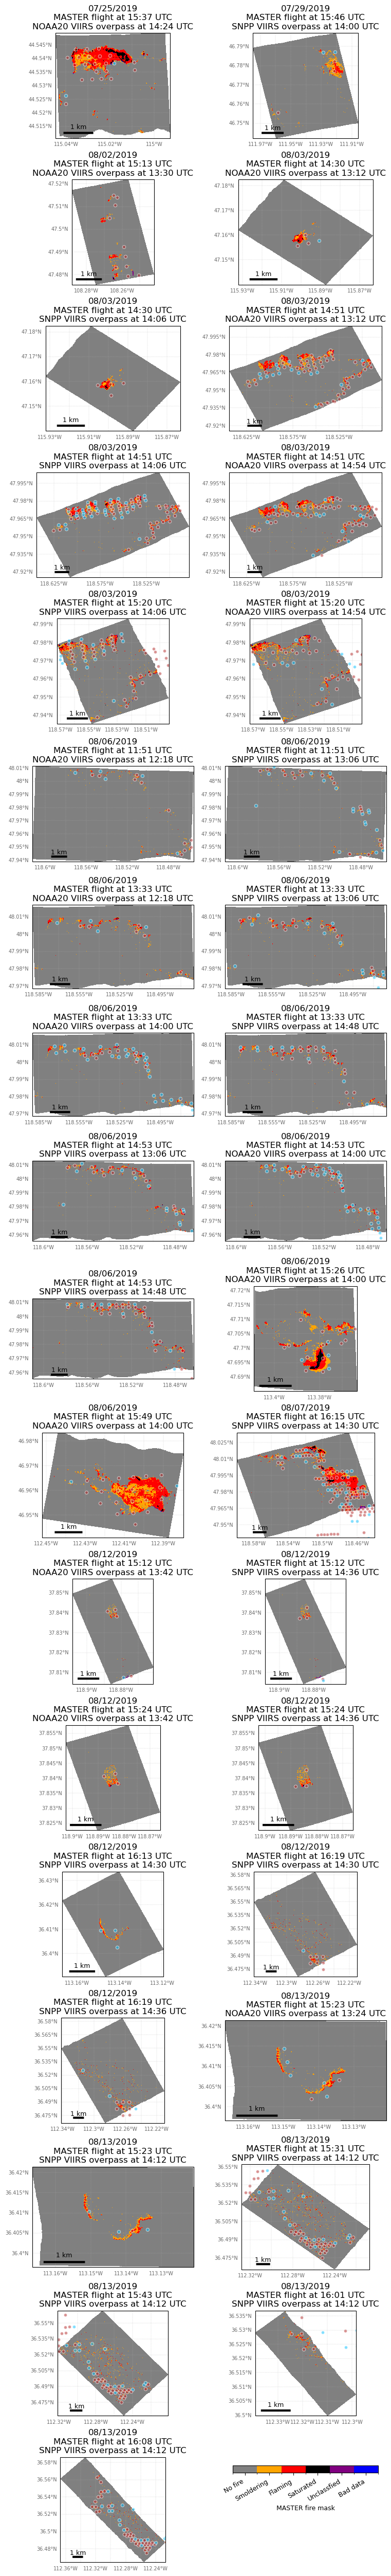

In [66]:
#modified version - plot all 35 together as subplots for Fig S2
master_dir = '/projects/shared-buckets/coffield/master/2019/'
files = os.listdir(master_dir)
files = sorted([f for f in files if f[-2:]=='nc'])

fig, axs = plt.subplots(18,2, subplot_kw={'projection': ccrs.Miller()}, constrained_layout=True, figsize=(7.5,50))
axs = axs.flat
a = 0

for file in files:
    data = xr.open_dataset(master_dir + file)
    date = dt.datetime.strptime(file[21:34], '%Y%m%d_%H%M').replace(tzinfo=dt.timezone.utc)
    
    locs = (data.MASK >0)    
    lon_mean = np.array(data.Longitude)[locs].mean()
    lat_mean = np.array(data.Latitude)[locs].mean()
    
    subset = dets[np.abs(dets.acq_datetime - date) < dt.timedelta(hours=2)] #within 2 hr
    subset = subset[(np.abs(subset.longitude - lon_mean) < 0.1) & (np.abs(subset.latitude - lat_mean) <0.1 )] 
    
    if len(subset) > 0:
        #plot them together, one for each unique matching overpass

        overpasses = np.unique(subset.acq_time)
        for overpass in overpasses:
            subsubset = subset[subset.acq_time==overpass]
    
            extent = [data.Longitude.min(),  data.Longitude.max(),  data.Latitude.min(), data.Latitude.max()]
            axs[a].set_extent(extent, crs=ccrs.PlateCarree())
                    
            plot = axs[a].pcolormesh(data.Longitude, data.Latitude, data.MASK, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)
    
            knowns = subsubset[subsubset.fire_mask > 6]
            cands = subsubset[subsubset.fire_mask < 7]
            axs[a].scatter(knowns.longitude, knowns.latitude, c='firebrick', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS known detections')
            axs[a].scatter(cands.longitude, cands.latitude, c='deepskyblue', edgecolors='1', s=20, alpha=0.5, transform=ccrs.Geodetic(), label='VIIRS candidate detections')

            mastertime = (date - dt.timedelta(hours=7)).strftime('%H:%M')
            viirstime = str(int(overpass[:2])-7) + overpass[2:]
            axs[a].set_title('{}\nMASTER flight at {} UTC\n{} VIIRS overpass at {} UTC'.format(date.strftime('%m/%d/%Y'), mastertime, subsubset.satellite.iloc[0], viirstime))


            import matplotlib.ticker as mticker
            from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

            gl = axs[a].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                              linewidth=0.2, color='0.7', linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlines = True
            gl.ylines = True
            #gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
            #gl.xformatter = LONGITUDE_FORMATTER
            #gl.yformatter = LATITUDE_FORMATTER
            gl.xlabel_style = {'size': 7, 'color': 'dimgray'}
            gl.ylabel_style = {'size': 7, 'color': 'dimgray'}

            scale_bar(axs[a], 1)
            
            a+=1

            #print NIFC fire name
            names = nifc_perimeters[nifc_perimeters.intersects(Point(lon_mean, lat_mean))].incidentname
            states = nifc_perimeters[nifc_perimeters.intersects(Point(lon_mean, lat_mean))].state

            #time delta, viirs - master
            difference = (subset.acq_datetime.iloc[0] - date).total_seconds() /60
            
            print(f"{date.strftime('%m/%d/%Y')},{mastertime},{subsubset.satellite.iloc[0]},{viirstime},{difference:.0f},{names.mode()[0].title()},{states.mode()[0]}")
            

#define colormap for MASTER fire mask
cmap = mpl.colors.ListedColormap(['gray','orange','red','black', 'purple','blue'])
bounds = [0,1,2,253,254,255,256]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
legend = ['0-No fire','1-Smoldering', '2-Flaming', '253-Saturated', '254-Unclassfied', '255-Bad data']
labels = [i.split('-')[1] for i in legend]

cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.9, pad=-1, ax=axs[-1])
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_xticks([0.5, 1.5, 127.5, 253.5, 254.5, 255.5])
cbar.ax.set_xticklabels(labels, rotation=30, ha='right')
cbar.set_label('MASTER fire mask', size=9)
#axs[-1].set_title('MASTER fire mask legend', fontsize=9)
axs[-1].axis('off')
#axs[-2].axis('off')

#plt.savefig('/projects/my-public-bucket/figures/figS2_gallery', dpi=250)